# AI Labour Market Exposure: An Empirical Analysis of the Anthropic Economic Index

This notebook analyses how Claude.ai usage is distributed across the U.S. labour market, using occupation and task-level data from the Anthropic Economic Index (February 2025 release), combined with Bureau of Labor Statistics employment and wage data. The central question is whether AI usage concentrates in particular occupations and wage levels disproportionately to their actual share of employment, and what that pattern suggests about the kind of work AI is currently being used for. The analysis independently reconstructs the Index's occupation-level methodology from the raw data, then extends it with original comparisons against employment share and wage data to test this question.

## Imports and Reading Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
sns.set_theme()

In [2]:
automation_vs_augmentation = pd.read_csv("data/automation_vs_augmentation.csv")
bls_employment = pd.read_csv("data/bls_employment_may_2023.csv")
task_mappings = pd.read_csv("data/onet_task_mappings.csv")
task_statements = pd.read_csv("data/onet_task_statements.csv")
soc_structure = pd.read_csv("data/SOC_Structure.csv")
wage_data = pd.read_csv("data/wage_data.csv")

## Data Understanding

Before merging these six datasets, each one needs checking for structure, granularity, and data quality issues that could affect how they are joined.

In [3]:
print(f"automation_vs_augmentation shape: {automation_vs_augmentation.shape}")
print(f"bls_employment shape: {bls_employment.shape}")
print(f"task_mappings shape: {task_mappings.shape}")
print(f"task_statements shape: {task_statements.shape}")
print(f"soc_structure shape: {soc_structure.shape}")
print(f"wage_data shape: {wage_data.shape}")

automation_vs_augmentation shape: (6, 2)
bls_employment shape: (22, 2)
task_mappings shape: (3514, 2)
task_statements shape: (19530, 8)
soc_structure shape: (1596, 6)
wage_data shape: (1090, 10)


In [4]:
automation_vs_augmentation.head()

,interaction_type,pct
0,directive,22.563272
1,feedback loop,12.036303
2,learning,18.917648
3,none,2.901302
4,task iteration,25.476487


In [5]:
bls_employment.head()

,SOC or O*NET-SOC 2019 Title,bls_distribution
0,Management Occupations,10495770
1,Business and Financial Operations Occupations,10087830
2,Computer and Mathematical Occupations,5177400
3,Architecture and Engineering Occupations,2539660
4,"Life, Physical, and Social Science Occupations",1389430


In [6]:
task_mappings.head()

,task_name,pct
0,act as advisers to student organizations.,0.006775
1,act as an advocate for farmers or farmers' gro...,0.002997
2,act as an intermediary in negotiations between...,0.012638
3,act as an intermediary in negotiations between...,0.011466
4,act as liaisons between clients and medical st...,0.001954


In [7]:
task_statements.head()

,O*NET-SOC Code,Title,Task ID,Task,Task Type,Incumbents Responding,Date,Domain Source
0,11-1011.00,Chief Executives,8823,Direct or coordinate an organization's financi...,Core,87.0,07/2014,Incumbent
1,11-1011.00,Chief Executives,8831,Appoint department heads or managers and assig...,Core,87.0,07/2014,Incumbent
2,11-1011.00,Chief Executives,8825,Analyze operations to evaluate performance of ...,Core,87.0,07/2014,Incumbent
3,11-1011.00,Chief Executives,8826,"Direct, plan, or implement policies, objective...",Core,87.0,07/2014,Incumbent
4,11-1011.00,Chief Executives,8827,"Prepare budgets for approval, including those ...",Core,87.0,07/2014,Incumbent


In [8]:
soc_structure.head()

,Major Group,Minor Group,Broad Occupation,Detailed Occupation,Detailed O*NET-SOC,SOC or O*NET-SOC 2019 Title
0,11-0000,NaN,NaN,NaN,NaN,Management Occupations
1,NaN,11-1000,NaN,NaN,NaN,Top Executives
2,NaN,NaN,11-1010,NaN,NaN,Chief Executives
3,NaN,NaN,NaN,11-1011,NaN,Chief Executives
4,NaN,NaN,NaN,NaN,11-1011.03,Chief Sustainability Officers


In [9]:
wage_data.head()

,SOCcode,JobName,JobFamily,isBright,isGreen,JobZone,MedianSalary,JobForecast,ChanceAuto,WageGroup
0,13-2011.01,Accountants,Business and Financial Operations,True,False,4,70500.00,146000,-1.0,Accountants and Auditors
1,13-2011.00,Accountants and Auditors,Business and Financial Operations,True,False,-1,70500.00,146000,94.0,NaN
2,27-2011.00,Actors,"Arts, Design, Entertainment, Sports, and Media",False,False,2,17.54,7700,37.0,NaN
3,15-2011.00,Actuaries,Computer and Mathematical,True,False,4,102880.00,2200,21.0,NaN
4,29-1199.01,Acupuncturists,Healthcare Practitioners and Technical,True,False,5,73960.00,3400,-1.0,"Health Diagnosing and Treating Practitioners, ..."


In [16]:
automation_vs_augmentation.isna().sum()

interaction_type    0
pct                 0
dtype: int64

In [17]:
bls_employment.isna().sum()

SOC or O*NET-SOC 2019 Title    0
bls_distribution               0
dtype: int64

In [18]:
task_mappings.isna().sum()

task_name    0
pct          0
dtype: int64

In [19]:
task_statements.isna().sum()

O*NET-SOC Code             0
Title                      0
Task ID                    0
Task                       0
Task Type                658
Incumbents Responding    658
Date                       0
Domain Source              0
dtype: int64

In [20]:
soc_structure.isna().sum()

Major Group                    1573
Minor Group                    1498
Broad Occupation               1137
Detailed Occupation             729
Detailed O*NET-SOC             1447
SOC or O*NET-SOC 2019 Title       0
dtype: int64

In [21]:
wage_data.isna().sum()

SOCcode           0
JobName           0
JobFamily         0
isBright          0
isGreen           0
JobZone           0
MedianSalary      0
JobForecast       0
ChanceAuto        0
WageGroup       795
dtype: int64

The near-complete NaN counts in `soc_structure`'s hierarchy columns (`Major Group`, `Minor Group`, and so on) reflect its structure rather than missing data, each row represents a single level of the SOC classification tree, so only one of these columns is populated per row. This is addressed directly in the next section by isolating rows with a valid `Major Group`.

## Data Cleaning and Merging

### Clean and Merge Occupation Data

In [67]:
task_statements["O*NET-SOC Code"].head()

0    11-1011.00
1    11-1011.00
2    11-1011.00
3    11-1011.00
4    11-1011.00
Name: O*NET-SOC Code, dtype: str

In [68]:
soc_structure["Major Group"].head()

0    11-0000
1        NaN
2        NaN
3        NaN
4        NaN
Name: Major Group, dtype: str

`O*NET-SOC Code` and `Major Group` don't share a common format directly, comparing the head of each column shows `Major Group` uses a broader 2-digit prefix that corresponds to the first two characters of the more detailed `O*NET-SOC Code`. Matching on that shared prefix is what makes this merge possible.

In [ ]:
soc_structure_clean = soc_structure.dropna(subset=["Major Group"])

task_statements["soc_major_group"] = task_statements["O*NET-SOC Code"].str[:2]
soc_structure_clean["soc_major_group"] = soc_structure_clean["Major Group"].str[:2]

task_occupations = task_statements.merge(
    soc_structure_clean[["soc_major_group", "SOC or O*NET-SOC 2019 Title"]],
    on="soc_major_group",
    how="left"
)

In [ ]:
# Drop columns not needed for the occupation-category mapping
task_occupations = task_occupations[['O*NET-SOC Code',
                                     'Title',
                                   # 'Task ID',
                                     'Task',
                                   # 'Task Type',
                                   # 'Incumbents Responding',
                                   # 'Date',
                                   # 'Domain Source',
                                     'soc_major_group',
                                     'SOC or O*NET-SOC 2019 Title']]

In [27]:
task_occupations.head()

,O*NET-SOC Code,Title,Task,soc_major_group,SOC or O*NET-SOC 2019 Title
0,11-1011.00,Chief Executives,Direct or coordinate an organization's financi...,11,Management Occupations
1,11-1011.00,Chief Executives,Appoint department heads or managers and assig...,11,Management Occupations
2,11-1011.00,Chief Executives,Analyze operations to evaluate performance of ...,11,Management Occupations
3,11-1011.00,Chief Executives,"Direct, plan, or implement policies, objective...",11,Management Occupations
4,11-1011.00,Chief Executives,"Prepare budgets for approval, including those ...",11,Management Occupations


In [28]:
task_occupations.shape

(19530, 5)

In [29]:
task_occupations.isna().sum()

O*NET-SOC Code                 0
Title                          0
Task                           0
soc_major_group                0
SOC or O*NET-SOC 2019 Title    0
dtype: int64

### Clean and Merge Usage Data

In [30]:
task_mappings["task_name"]

0               act as advisers to student organizations.
1       act as an advocate for farmers or farmers' gro...
2       act as an intermediary in negotiations between...
3       act as an intermediary in negotiations between...
4       act as liaisons between clients and medical st...
                              ...                        
3509    write, design, or edit web page content, or di...
3510    write, present, and publish reports that recor...
3511    write, review, or execute plans for testing ne...
3512    write, review, or maintain engineering documen...
3513    write, update, and maintain computer programs ...
Name: task_name, Length: 3514, dtype: str

In [31]:
task_occupations["Task"]

0        Direct or coordinate an organization's financi...
1        Appoint department heads or managers and assig...
2        Analyze operations to evaluate performance of ...
3        Direct, plan, or implement policies, objective...
4        Prepare budgets for approval, including those ...
                               ...                        
19525    Test vessels for leaks, damage, and defects, a...
19526    Unload cars containing liquids by connecting h...
19527    Copy and attach load specifications to loaded ...
19528    Start pumps and adjust valves or cables to reg...
19529    Perform general warehouse activities, such as ...
Name: Task, Length: 19530, dtype: str

`task_mappings["task_name"]` and `task_occupations["Task"]` should represent the same task text, but come from different sources, so their formatting needs checking before they can be matched directly. Comparing the two shows inconsistencies in case and whitespace that need resolving first.

In [ ]:
task_mappings["Task"] = task_mappings["task_name"].str.lower().str.strip()
task_occupations["Task"] = task_occupations["Task"].str.lower().str.strip()

task_usage = task_mappings.merge(
    task_occupations,
    on="Task",
    how="left"
)

# task_name is now redundant since Task was used for the merge
task_usage = task_usage.drop("task_name", axis=1)

In [33]:
task_usage.head()

,pct,Task,O*NET-SOC Code,Title,soc_major_group,SOC or O*NET-SOC 2019 Title
0,0.006775,act as advisers to student organizations.,25-1011.00,"Business Teachers, Postsecondary",25,Educational Instruction and Library Occupations
1,0.006775,act as advisers to student organizations.,25-1021.00,"Computer Science Teachers, Postsecondary",25,Educational Instruction and Library Occupations
2,0.006775,act as advisers to student organizations.,25-1022.00,"Mathematical Science Teachers, Postsecondary",25,Educational Instruction and Library Occupations
3,0.006775,act as advisers to student organizations.,25-1031.00,"Architecture Teachers, Postsecondary",25,Educational Instruction and Library Occupations
4,0.006775,act as advisers to student organizations.,25-1032.00,"Engineering Teachers, Postsecondary",25,Educational Instruction and Library Occupations


Each row in `task_mappings` gives a usage percentage (`pct`) for a single task, but the same task description can belong to multiple occupations, "act as advisers to student organizations." for example, appears as a task under several different job titles. Merging on `Task` therefore duplicates that task's `pct` value across every occupation that shares it, which would inflate usage share if summed later. For example, a task shared by five occupations would get counted five times over rather than once. `n_occurrences` counts how many distinct occupations each task is associated with, and dividing `pct` by that count spreads the usage share evenly across them, so that summing `pct_scaled` across occupations or categories later reflects the task's true total usage rather than an inflated, duplicated total.

In [ ]:
task_usage["n_occurrences"] = task_usage.groupby("Task")["Title"].transform("nunique")
task_usage["pct_scaled"] = task_usage["pct"] / task_usage["n_occurrences"]

# Rename to distinguish from pct_scaled
task_usage = task_usage.rename(columns={"pct": "pct_raw"})

In [35]:
task_usage.head()

,pct_raw,Task,O*NET-SOC Code,Title,soc_major_group,SOC or O*NET-SOC 2019 Title,n_occurrences,pct_scaled
0,0.006775,act as advisers to student organizations.,25-1011.00,"Business Teachers, Postsecondary",25,Educational Instruction and Library Occupations,34,0.000199
1,0.006775,act as advisers to student organizations.,25-1021.00,"Computer Science Teachers, Postsecondary",25,Educational Instruction and Library Occupations,34,0.000199
2,0.006775,act as advisers to student organizations.,25-1022.00,"Mathematical Science Teachers, Postsecondary",25,Educational Instruction and Library Occupations,34,0.000199
3,0.006775,act as advisers to student organizations.,25-1031.00,"Architecture Teachers, Postsecondary",25,Educational Instruction and Library Occupations,34,0.000199
4,0.006775,act as advisers to student organizations.,25-1032.00,"Engineering Teachers, Postsecondary",25,Educational Instruction and Library Occupations,34,0.000199


In [36]:
task_usage.shape

(4245, 8)

In [37]:
task_usage.isna().sum()

pct_raw                        0
Task                           0
O*NET-SOC Code                 1
Title                          1
soc_major_group                1
SOC or O*NET-SOC 2019 Title    1
n_occurrences                  0
pct_scaled                     0
dtype: int64

In [38]:
task_usage[task_usage["O*NET-SOC Code"].isna()]

,pct_raw,Task,O*NET-SOC Code,Title,soc_major_group,SOC or O*NET-SOC 2019 Title,n_occurrences,pct_scaled
2482,0.481557,none,NaN,NaN,NaN,NaN,0,inf


This row's `Task` value is literally the string `"none"`, a placeholder in the source data rather than a real task, which matched nothing in the occupation data and caused a division-by-zero in `pct_scaled`. It's dropped since it carries no usable information.

In [39]:
task_usage = task_usage[task_usage["Task"] != "none"]

### Merge in BLS Employment Data and Compute Representation Gap

`bls_employment` reports employment at the category level, while `task_usage` is still at the task-occupation level, so the two can't be merged directly. Collapsing `task_usage` to one row per category and summing `pct_scaled`, matches the grain `bls_employment` is already at.

In [ ]:
category_usage = (
    task_usage
    .groupby("SOC or O*NET-SOC 2019 Title")["pct_scaled"]
    .sum()
    .reset_index()
)

In [ ]:
category_comparison = category_usage.merge(
    bls_employment,
    on="SOC or O*NET-SOC 2019 Title",
    how="left"
)

In [42]:
# Add column for percentage of total employment
category_comparison["bls_pct"] = 100 * category_comparison["bls_distribution"] / category_comparison["bls_distribution"].sum()

# Add column to show over/under representation of AI usage per category
category_comparison["bls_pct_diff"] = category_comparison["pct_scaled"] - category_comparison["bls_pct"]

# Add column to show relative AI usage per category
category_comparison["bls_pct_ratio"] = category_comparison["pct_scaled"] / category_comparison["bls_pct"]

In [43]:
category_comparison.head()

,SOC or O*NET-SOC 2019 Title,pct_scaled,bls_distribution,bls_pct,bls_pct_diff,bls_pct_ratio
0,Architecture and Engineering Occupations,4.492189,2539660,1.672437,2.819752,2.686014
1,"Arts, Design, Entertainment, Sports, and Media...",10.227880,2106490,1.387182,8.840697,7.373133
2,Building and Grounds Cleaning and Maintenance ...,0.098240,4429070,2.916666,-2.818426,0.033682
3,Business and Financial Operations Occupations,5.899402,10087830,6.643117,-0.743715,0.888047
4,Community and Social Service Occupations,2.064090,2418130,1.592406,0.471684,1.296209


In [44]:
category_comparison.shape

(22, 6)

In [45]:
category_comparison.isna().sum()

SOC or O*NET-SOC 2019 Title    0
pct_scaled                     0
bls_distribution               0
bls_pct                        0
bls_pct_diff                   0
bls_pct_ratio                  0
dtype: int64

### Merge in Wage Data

`wage_data` reports one salary per occupation, while `task_usage` is still at the task-occupation level, so it needs collapsing to one row per occupation first, summing `pct_scaled`, before it can be merged with wage.

In [46]:
occupation_usage = (
    task_usage
    .groupby(["O*NET-SOC Code", "Title"])["pct_scaled"]
    .sum()
    .reset_index()
)

In [ ]:
# SOCcode is O*NET-SOC Code under a different name
occupation_comparison = occupation_usage.merge(
    wage_data,
    left_on="O*NET-SOC Code",
    right_on="SOCcode",
    how="left"
)

In [ ]:
# Drop columns not needed for the wage comparison
occupation_comparison = occupation_comparison[['O*NET-SOC Code', 'Title', 'pct_scaled',
                                             # 'SOCcode', 'JobName', 'JobFamily',
                                             # 'isBright', 'isGreen', 'JobZone',
                                               'MedianSalary',
                                             # 'JobForecast', 'ChanceAuto', 'WageGroup'
                                             ]]

In [50]:
occupation_comparison.head()

,O*NET-SOC Code,Title,pct_scaled,MedianSalary
0,11-1011.00,Chief Executives,0.382927,189600.0
1,11-1011.03,Chief Sustainability Officers,0.006515,189600.0
2,11-1021.00,General and Operations Managers,0.124298,100930.0
3,11-1031.00,Legislators,0.031400,24670.0
4,11-2011.00,Advertising and Promotions Managers,0.193613,117130.0


In [51]:
occupation_comparison.shape

(756, 4)

In [52]:
occupation_comparison.isna().sum()

O*NET-SOC Code    0
Title             0
pct_scaled        0
MedianSalary      0
dtype: int64

## Data Visualisation

### AI Usage Share vs Employment Share by Occupation Category

Categories are sorted by `bls_pct_diff` so the chart runs from most under-represented to most over-represented, making the overall pattern easier to scan. A value of zero in `bls_pct_diff` means an occupation's usage share exactly matches its employment share, so the colour mapping is centered on that point rather than the midpoint of the data's actual range. A diverging colormap then reinforces the direction each bar already shows through its position, making both direction and magnitude easier to read at a glance.

In [ ]:
category_comparison_sorted_diff = category_comparison.sort_values(by="bls_pct_diff")

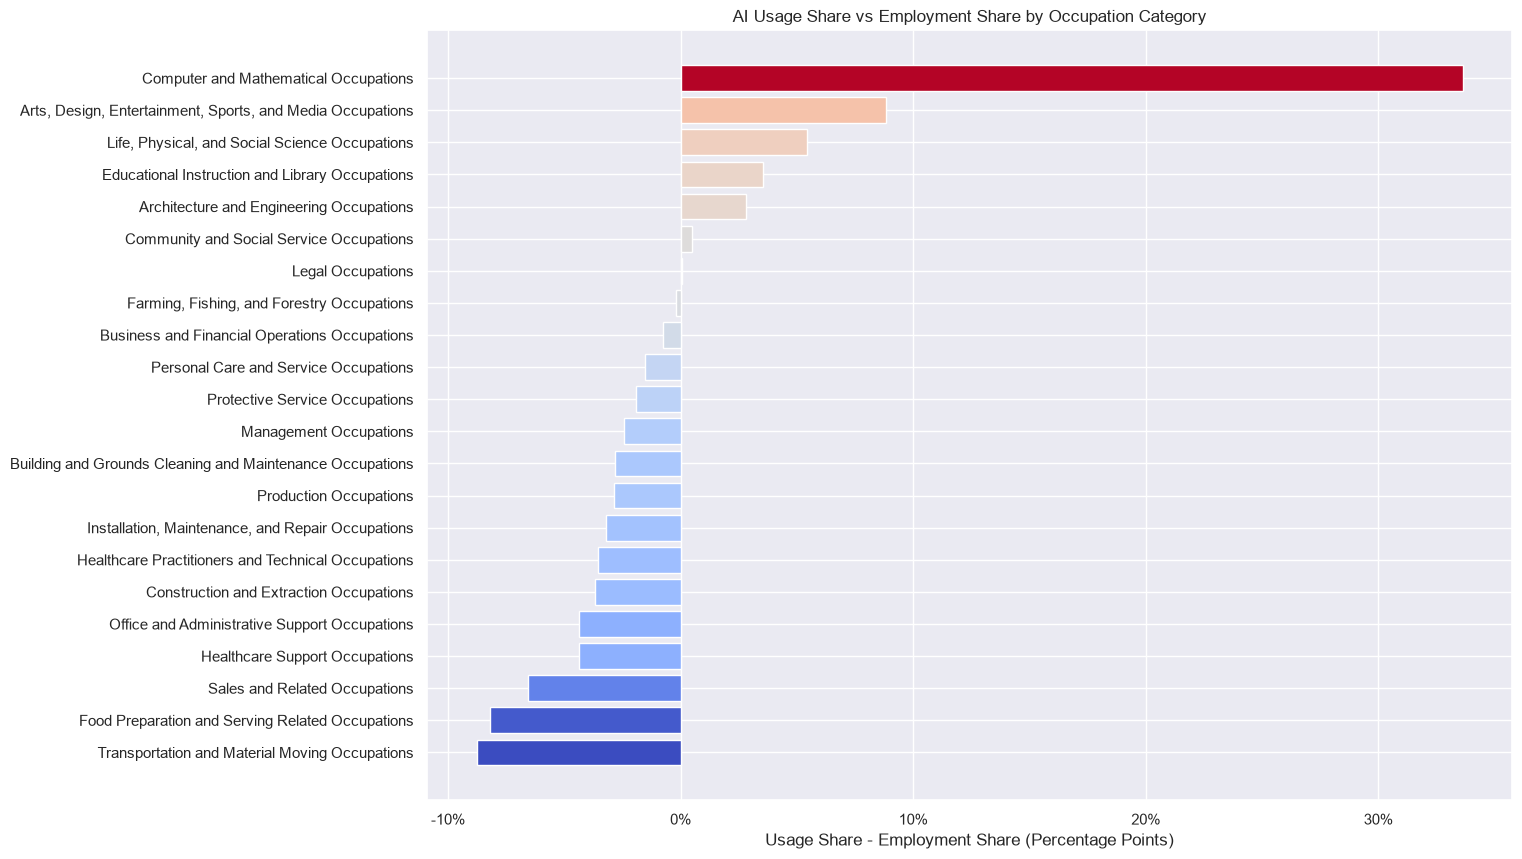

In [83]:
norm = mcolors.TwoSlopeNorm(
    vmin=category_comparison_sorted_diff["bls_pct_diff"].min(),
    vcenter=0,
    vmax=category_comparison_sorted_diff["bls_pct_diff"].max()
    )
colors = plt.cm.coolwarm(norm(category_comparison_sorted_diff["bls_pct_diff"]))

fig, ax = plt.subplots(figsize=(14, 10))
ax.barh(category_comparison_sorted_diff["SOC or O*NET-SOC 2019 Title"], category_comparison_sorted_diff["bls_pct_diff"], color=colors)
ax.set_title("AI Usage Share vs Employment Share by Occupation Category")
ax.set_xlabel("Usage Share - Employment Share (Percentage Points)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
plt.show()

### AI Usage Relative to Employment Share by Occupation Category

`bls_pct_ratio` is bounded between 0 and 1 for under-representation but unbounded above 1 for over-representation. This compresses most of the meaningful variation into a narrow range on a linear scale and makes the two directions hard to compare. Taking log2 of the ratio makes both directions symmetric, doubling and halving become equal distances from zero, and each whole step represents a doubling or halving of representation relative to employment share. This is a more interpretable unit than the raw ratio.

In [89]:
category_comparison["log2_ratio"] = np.log2(category_comparison["bls_pct_ratio"])
category_comparison_sorted_ratio = category_comparison.sort_values(by="log2_ratio")

Categories are sorted by `log2_ratio` so the chart runs from most under-represented to most over-represented, the same ordering logic as the previous chart. A value of zero in `log2_ratio` means proportional representation, the same point `bls_pct_diff` of zero represented there. Hence, the colour mapping is again centered on zero, with a diverging colormap reinforcing the direction each bar already shows through its position.

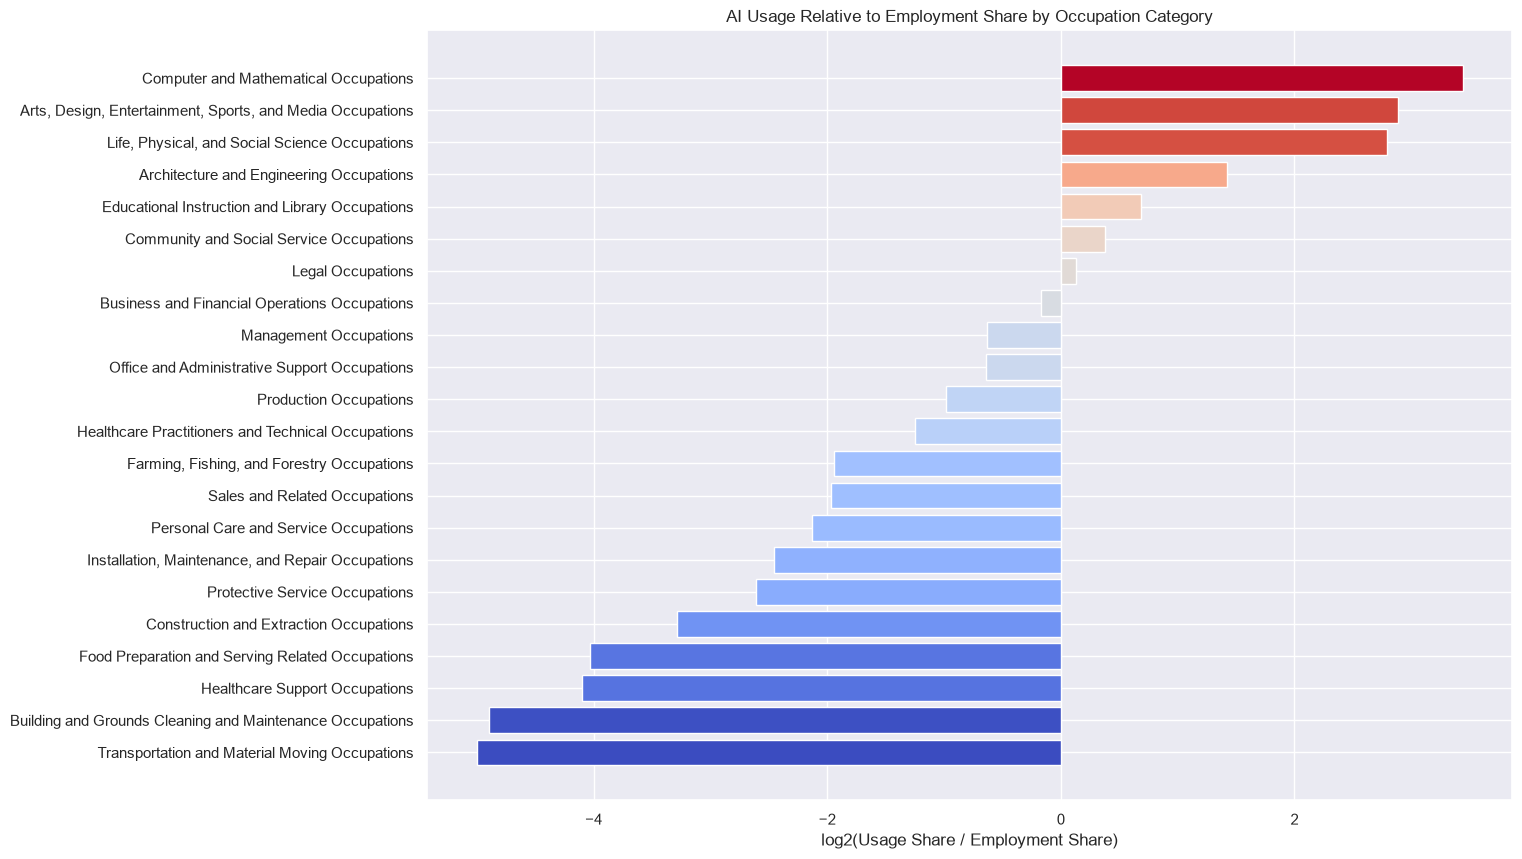

In [90]:
norm = mcolors.TwoSlopeNorm(
    vmin=category_comparison_sorted_ratio["log2_ratio"].min(),
    vcenter=0,
    vmax=category_comparison_sorted_ratio["log2_ratio"].max()
)
colors = plt.cm.coolwarm(norm(category_comparison_sorted_ratio["log2_ratio"]))

fig, ax = plt.subplots(figsize=(14, 10))
ax.barh(category_comparison_sorted_ratio["SOC or O*NET-SOC 2019 Title"], category_comparison_sorted_ratio["log2_ratio"], color=colors)
ax.set_title("AI Usage Relative to Employment Share by Occupation Category")
ax.set_xlabel("log2(Usage Share / Employment Share)")
plt.show()

### AI Usage Share vs Median Salary by Occupation

Checking the distribution of both variables before plotting, to understand their spread and spot anything worth investigating before building the chart.

In [58]:
occupation_comparison["pct_scaled"].describe()

count    756.000000
mean       0.131638
std        0.417186
min        0.001954
25%        0.010684
50%        0.032117
75%        0.092051
max        6.128259
Name: pct_scaled, dtype: float64

In [59]:
occupation_comparison["MedianSalary"].describe()

count       756.000000
mean      64792.539881
std       34451.541311
min          16.310000
25%       40322.500000
50%       58825.000000
75%       79737.500000
max      208000.000000
Name: MedianSalary, dtype: float64

`pct_scaled` ranges from 0.002 to 6.13, roughly 190 times its median, a heavily skewed distribution, while `MedianSalary` is far more evenly spread, its max is only about 3.5 times its median. Rather than log-transforming the skewed axis, this is handled directly in the chart itself, through transparency, formatted axis labels, and annotating only the most usage-heavy occupations. This keeps the actual dollar differences between salary levels intuitive to read rather than compressed.

In [60]:
occupation_comparison[occupation_comparison["MedianSalary"] < 10000]

,O*NET-SOC Code,Title,pct_scaled,MedianSalary
352,27-2011.00,Actors,0.780446,17.54
360,27-2031.00,Dancers,0.004169,16.31
364,27-2042.01,Singers,0.034527,28.15
365,27-2042.02,"Musicians, Instrumental",0.016026,28.15


These four occupations all have implausibly low figures for an annual salary. This reflects a known BLS convention: for occupations without a meaningful full-time annual wage, hourly rates are reported instead. Multiplying by 2080, the standard full-time annual hours (40 hours * 52 weeks), converts these back to a comparable annual figure.

In [ ]:
occupation_comparison.loc[occupation_comparison["MedianSalary"] < 1000, "MedianSalary"] *= 2080
occupation_comparison[occupation_comparison["MedianSalary"] < 10000]

,O*NET-SOC Code,Title,pct_scaled,MedianSalary


In [ ]:
occupation_comparison["pct_scaled"].corr(occupation_comparison["MedianSalary"])

np.float64(0.08833807651051379)

A correlation of roughly 0.09 is very weak, but this only measures a straight-line relationship. If usage actually peaks somewhere in the middle of the wage range rather than rising steadily with wage, a linear correlation would understate that pattern entirely. The scatter below is what actually reveals the shape.

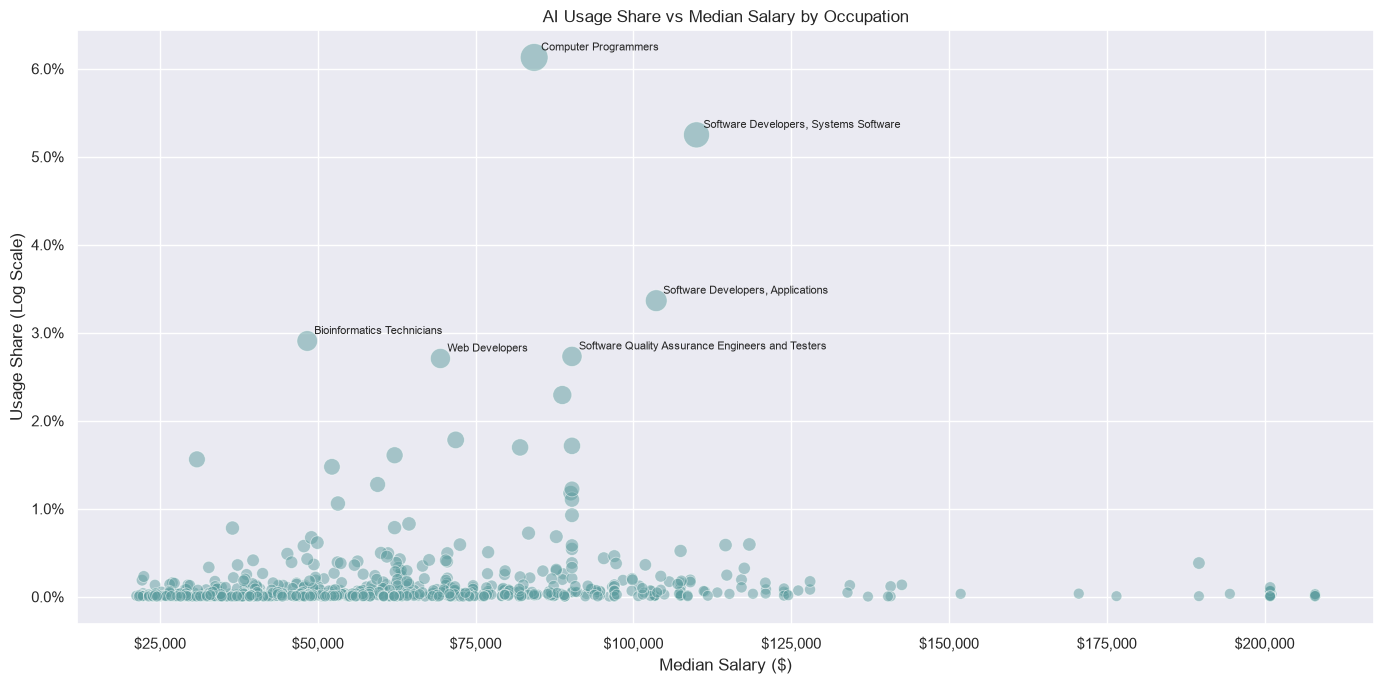

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))
sns.scatterplot(data=occupation_comparison, x="MedianSalary", y="pct_scaled",
                size="pct_scaled", sizes=(60, 400), alpha=0.5, legend=False,
                color="cadetblue", ax=ax)

ax.set_xlabel("Median Salary ($)")
ax.set_ylabel("Usage Share")
ax.set_title("AI Usage Share vs Median Salary by Occupation")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1f}%"))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))


# Label only the highest-usage occupations to keep the chart readable
top_n = occupation_comparison.nlargest(6, "pct_scaled")
for _, row in top_n.iterrows():
    ax.annotate(row["Title"], (row["MedianSalary"], row["pct_scaled"]),
                xytext=(5, 5), textcoords="offset points", fontsize=8)

plt.tight_layout()
plt.show()

### Automation vs Augmentation: Interaction Type Breakdown

In [64]:
automation_vs_augmentation

,interaction_type,pct
0,directive,22.563272
1,feedback loop,12.036303
2,learning,18.917648
3,none,2.901302
4,task iteration,25.476487
5,validation,2.314220


In [ ]:
automation_vs_augmentation["pct"].sum()

np.float64(84.20923280635584)

All six interaction types, including `none`, sum to only 84.2%, not 100%, roughly 15.8% isn't accounted for by any of these categories. Excluding `none` and renormalising the remaining five to sum to 100% reproduces the paper's published breakdown exactly, confirming this is how those figures were derived, though the source of the unaccounted-for share isn't clear from this data alone.

In [94]:
avg_df = automation_vs_augmentation[automation_vs_augmentation["interaction_type"] != "none"].copy()
avg_df["pct_normalised"] = 100 * avg_df["pct"] / avg_df["pct"].sum()

# Categorise each interaction type using the automation/augmentation grouping from the source paper
supercategory_map = {
    "directive": "Automation",
    "feedback loop": "Automation",
    "learning": "Augmentation",
    "task iteration": "Augmentation",
    "validation": "Augmentation"
}

avg_df["supercategory"] = avg_df["interaction_type"].map(supercategory_map)

# reshape to wide format so each supercategory's interaction types can be stacked
pivot_df = avg_df.pivot(index="supercategory", columns="interaction_type", values="pct_normalised").fillna(0)

In [95]:
pivot_df

interaction_type,directive,feedback loop,learning,task iteration,validation
supercategory,,,,,
Augmentation,0.000000,0.000000,23.26667,31.333335,2.846242
Automation,27.750396,14.803357,0.00000,0.000000,0.000000


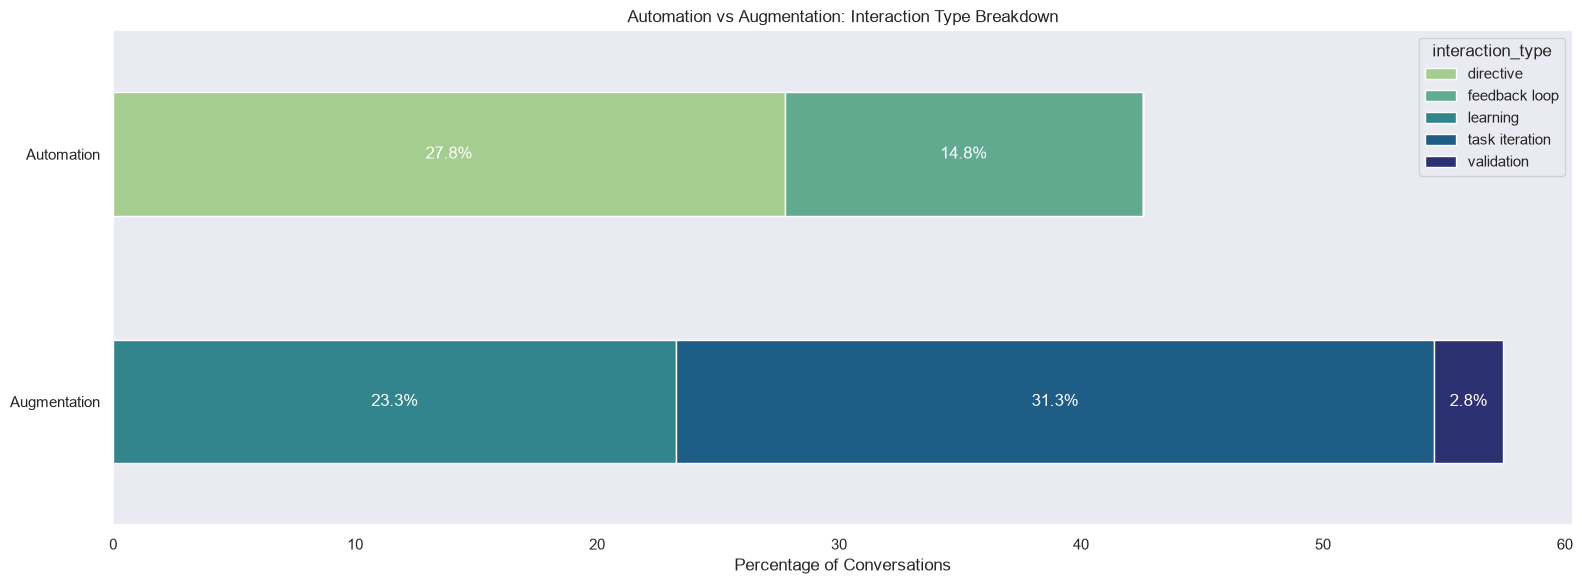

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))
pivot_df.plot(kind="barh", stacked=True, colormap="crest", ax=ax)

for container in ax.containers:
# Suppress the 0% label for supercategories that don't include a given interaction type
    labels = [f"{v:.1f}%" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", color="white")

ax.set_xlabel("Percentage of Conversations")
ax.set_ylabel("")
ax.set_title("Automation vs Augmentation: Interaction Type Breakdown")
plt.grid(False)
plt.tight_layout()
plt.show()